# Renoir Downstream Toolkit: A Complete Showcase

This notebook is a **comprehensive reference** for every downstream analysis tool that **Renoir** offers, demonstrated end-to-end on a precomputed neighborhood-score matrix. If you've already produced a `neighborhood_scores` object from `Renoir.compute_neighborhood_scores` (see the [Visium](https://renoir.readthedocs.io/en/latest/notebooks/renoir_visium_tutorial.html) and [CosMx](https://renoir.readthedocs.io/en/latest/notebooks/renoir_cosmx_tutorial.html) tutorials), this notebook walks through everything you can do with it.

> **Scope.** We assume `neighborhood_scores` (and the supporting tables for ligand ranking) have already been computed and saved to disk. We **load**, not compute, so the focus stays on the downstream tools themselves.

## Overview

| # | Tool | What it does |
|---|---|---|
| 1 | `sc.pl.spatial` (single pair) | Spatial map of one ligand–target pair |
| 2 | `Renoir.create_cluster` (pathway mode) | Group L–T pairs by curated MSigDB pathways |
| 3 | `Renoir.create_cluster` (de novo mode) | Group L–T pairs by data-driven clustering |
| 4 | `Renoir.downstream_analysis` | Leiden communication domains + pathway PC AnnData |
| 5 | Spatial domain map | Visualize communication domains in tissue |
| 6 | `sc.tl.rank_genes_groups` + heatmap | DE ligand–target pairs per domain |
| 7 | Pathway activity in space | Visualize one pathway's spatial activity |
| 8 | `Renoir.pcs_v_neighbscore` | Pathway-vs-pair contribution heatmaps + spatial plots |
| 9 | `Renoir.ligand_ranking` | Rank ligands driving a chosen domain |
| 10 | `Renoir.downstream.sankeyPlot` | Sankey of ligand → target → cell type → domain flow |

## Dataset

We use the **Triple-Negative Breast Cancer Visium** dataset from [Wu et al., *Nature Genetics* 2021](https://www.nature.com/articles/s41588-021-00911-1#data-availability) — the same data as the Visium tutorial — but with `neighborhood_scores` already computed and pickled on disk.


> Update the file paths in section 0 to point at your own data before running.


## 0. Setup: imports and data loading

In [1]:
import Renoir
from Renoir import downstream as rd  # exposes sankeyPlot, pcs_v_neighbscore, etc.

import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import pickle
import matplotlib.pyplot as plt

# Comfortable default size for Visium spatial plots
plt.rcParams['figure.figsize'] = [8, 8]


/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


### Load the precomputed neighborhood scores


In [2]:
# Path to the saved neighborhood scores AnnData
NBSCORES_PATH = '/path/to/neighborhood_scores.h5ad'

neighborhood_scores = sc.read_h5ad(NBSCORES_PATH)
neighborhood_scores


AnnData object with n_obs × n_vars = 1322 × 3491
    obs: 'in_tissue', 'array_row', 'array_col', 'classification'
    var: 'gene_ids'
    uns: 'spatial'
    obsm: 'spatial'

### Load the supporting tables for ligand ranking and Sankey

Some of the downstream tools (`ligand_ranking`, `sankeyPlot`) need extra inputs beyond the score matrix:

- **`celltype`** — AnnData with per-spot cell-type proportions (typically the cell2location output).
- **`SC`** — the matched scRNA-seq reference, used to measure receptor expression per cell type.
- **`ligand_receptor_pairs`** — curated L–R table (e.g., NATMI / OmniPath).
- **`ligand_target_regulatory_potential`** — a precomputed pickle of ligand → top-N target regulatory scores (NicheNet-style).
- **`celltype_colors`** — a custom palette so cell types render with consistent colors across all plots.

We also stash a copy of `neighborhood_scores` into `.raw` so functions that internally call `rank_genes_groups` can recover the unmodified scores afterward.


In [3]:
# --- File paths (edit to match your environment) ---
CELLTYPE_PATH       = '/path/to/celltype.h5ad'
SCRNA_PATH          = '/path/to/scRNA.h5ad'
LR_PAIRS_PATH       = '/path/to/NATMI_ligand_receptor_pairs.csv'
LT_REG_POTENTIAL    = '/path/to/top_500_target_opt_both_scores.pkl'
MSIG_PATH           = '/path/to/msig_human_WP_H_KEGG_new.csv'

# --- Load everything ---
celltype = sc.read_h5ad(CELLTYPE_PATH)
SC       = sc.read_h5ad(SCRNA_PATH)

ligand_receptor_pairs = pd.read_csv(LR_PAIRS_PATH)
ligand_target_regulatory_potential = pickle.load(open(LT_REG_POTENTIAL, 'rb'))

# Custom palette so cell-type colors stay consistent across plots
celltype_colors = {
    'Cancer Basal SC':      '#4a6e45',
    'Cancer Cycling':       '#8727a8',
    'T cells CD4+':         '#f19bf6',
    'CAFs myCAF-like':      '#919225',
    'T cells CD8+':         '#861c1c',
    'PVL Differentiated':   '#cc9900',
    'CAFs MSC iCAF-like':   '#0099ff',
    'Luminal Progenitors':  '#b12a55',
    'Mature Luminal':       '#906e1f',
    'Myoepithelial':        '#a48cf4',
    'Endothelial ACKR1':    '#f45cf2',
    'Macrophage':           '#f66bad',
    'Plasmablasts':         '#ffff00',
}

# Stash the score matrix so downstream functions can reach the raw values
neighborhood_scores.raw = neighborhood_scores.copy()


## 1. Spatial map of a single ligand–target pair

The simplest exploratory view: paint one pair's score onto the tissue. Each spot is colored by the activity score for that pair, so bright regions are areas where the ligand from neighboring spots is predicted to be inducing the target gene in the focal spot.

We'll use **`LAMB1:MYC`** — laminin-beta-1 driving MYC expression.

### About the arguments
- `img_key="hires"` — overlay on the high-resolution tissue image stored in `uns['spatial']`.
- `size=1.4` — scale up the spot dots so they actually fill the hex grid.
- `alpha_img=0` — make the underlying H&E fully transparent. Set to `0.5` to see histology underneath.


/tmp/ipykernel_2546534/1519112388.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


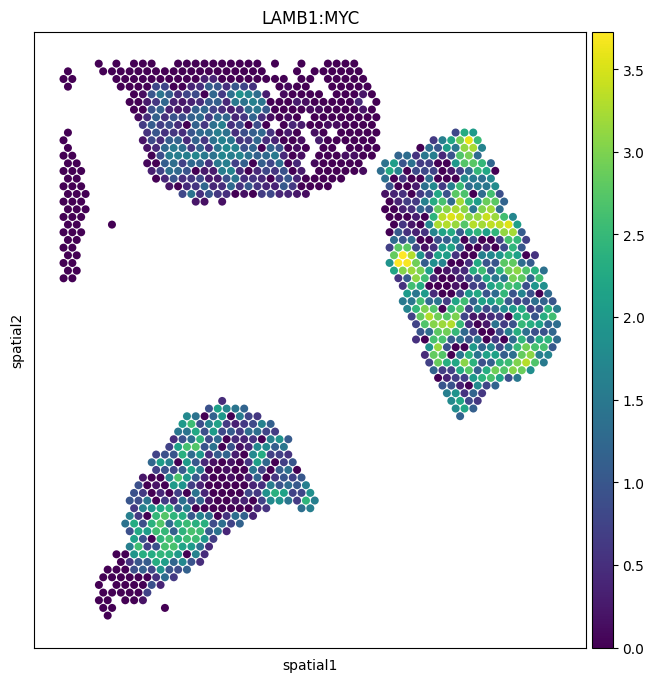

In [4]:
sc.pl.spatial(
    neighborhood_scores,
    img_key="hires",
    color=["LAMB1:MYC"],
    size=1.4,
    alpha_img=0,
)


## 2. `Renoir.create_cluster` — Pathway-based ligand–target clusters

`create_cluster` groups ligand–target pairs into **clusters** so you can score whole biological programs at once.

This section shows the **pathway-based** mode: each gene set in MSigDB becomes a cluster of all L–T pairs whose target gene is in that set.

### Key arguments

| Argument | Meaning |
|---|---|
| `neighbscore` | The neighborhood-scores AnnData. |
| `msig` | Pathway DataFrame with columns **`gs_name`** (gene-set name) and **`gene_symbol`** (target gene). |
| `method` | Set to `None` to skip de novo clustering and only build pathway clusters. |
| `pathway_thresh=4` | Minimum pairs per pathway cluster (default 4). |
| `restrict_to_KHW=True` | Keep only KEGG / Hallmark / WikiPathways (filter on `gs_name` prefix). |
| `use_pathway` / `pathway_path` | Optionally subset MSigDB to a custom pathway list. |

The function returns a dict mapping each pathway name to its list of ligand–target pairs.

> `Renoir.get_msig` is a small loader that reads the MSigDB CSV and returns a DataFrame in the right shape. You can also supply your own dataframe directly.


In [6]:
# Load curated MSigDB pathways (Hallmark + KEGG + WikiPathways, human)
msigh = Renoir.get_msig('custom', path=MSIG_PATH)

# Build one ligand-target cluster per pathway
pathways = Renoir.create_cluster(
    neighborhood_scores,
    msigh,
    method=None,            # pathway-based only
    pathway_thresh=20,       # minimum pairs per pathway
    restrict_to_KHW=True,   # KEGG / HALLMARK / WP only
)

# Number of pathways retained, plus a peek at the names
print(f'Retained {len(pathways)} pathway clusters')
list(pathways.keys())[:10]


Retained 20 pathway clusters


['HALLMARK_ALLOGRAFT_REJECTION',
 'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION',
 'HALLMARK_INFLAMMATORY_RESPONSE',
 'HALLMARK_TNFA_SIGNALING_VIA_NFKB',
 'KEGG_CHEMOKINE_SIGNALING_PATHWAY',
 'KEGG_CYTOKINE_CYTOKINE_RECEPTOR_INTERACTION',
 'KEGG_FOCAL_ADHESION',
 'KEGG_PATHWAYS_IN_CANCER',
 'WP_ALLOGRAFT_REJECTION',
 'WP_BURN_WOUND_HEALING']

## 3. `Renoir.create_cluster` — De novo ligand–target clusters

Sometimes the pathways you care about aren't in any curated database — particularly for tumor-specific or developmental programs. **De novo** clustering groups ligand–target pairs purely by similarity in their score profiles across spots, with no prior knowledge.

Renoir supports two de novo methods:

- `method='dhc'` — Divisive Hierarchical Clustering (default).
- `method='hdbscan'` — density-based; respect `minpts` to control minimum cluster size.

### Key arguments
- `method='dhc'` or `'hdbscan'` — pick the algorithm.
- `minpts=3` — minimum cluster size for HDBSCAN.
- `ltclust_thresh=6` — minimum pairs per de novo cluster (default 6, slightly higher than for pathways since these clusters are unsupervised and noisier).

If you also pass a pathway dataframe (`msig`), the function returns **both** the pathway clusters **and** the de novo clusters in the same dict, with de novo clusters keyed by names like `cluster_0`, `cluster_1`, ….


In [10]:
# De novo + pathway clusters in one go
all_clusters = Renoir.create_cluster(
    neighborhood_scores,
    msigh,
    method='dhc',           # de novo via divisive hierarchical clustering
    ltclust_thresh=30,       # minimum pairs per de novo cluster
    restrict_to_KHW=True,
)

# Separate de novo from pathway clusters by key prefix
de_novo  = {k: v for k, v in all_clusters.items() if k.startswith('cluster_')}

print(f'{len(pathways)} pathway clusters + {len(de_novo)} de novo clusters')
list(de_novo.keys())


/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/Renoir/downstream.py:102: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link = linkage(dist, "average")


..cutHeight not given, setting it to 139.18467115835463  ===>  99% of the (truncated) height range in dendro.
..done.
20 pathway clusters + 24 de novo clusters


['cluster_24',
 'cluster_2',
 'cluster_3',
 'cluster_4',
 'cluster_1',
 'cluster_6',
 'cluster_5',
 'cluster_7',
 'cluster_12',
 'cluster_9',
 'cluster_19',
 'cluster_11',
 'cluster_8',
 'cluster_10',
 'cluster_22',
 'cluster_17',
 'cluster_15',
 'cluster_20',
 'cluster_21',
 'cluster_13',
 'cluster_14',
 'cluster_18',
 'cluster_16',
 'cluster_23']

## 4. `Renoir.downstream_analysis` — Communication domains + pathway PCs

This is the workhorse. A **communication domain** is a group of spots with similar L–T activity profiles — i.e., regions where the same signaling programs are active. Renoir derives them by reducing the score matrix to PCs (one PC space per pathway cluster), concatenating, and Leiden-clustering the result.

### What it returns (with both flags on)

- `neighbscore_copy` — a copy of the AnnData with `obs['leiden']` populated (one label per spot = its domain).
- `pcs` — an AnnData where `.var` is one row per pathway cluster, so `pcs.X` is the per-spot pathway activity matrix.

### Key arguments

| Argument | Meaning |
|---|---|
| `ltpair_clusters` | Dict from `create_cluster` (use `pathways` for curated only, `all_clusters` to include de novo). |
| `resolution=0.6` | Leiden resolution. Lower → fewer, broader domains; higher → more, finer ones. |
| `n_markers=20` | How many top marker pairs per cluster to retain. |
| `n_top=20` | How many highly expressed pairs to display per domain. |
| `pdf_path=None` | Set to a filepath to dump diagnostic plots to PDF. |
| `return_cluster=True` | Return the score AnnData with Leiden labels. |
| `return_pcs=True` | Return the pathway-PC AnnData. |

> Internally this calls `scanpy`'s `rank_genes_groups`. For more flexibility, run that step yourself (see section 6).


In [12]:
neighbscore_copy, pcs = Renoir.downstream_analysis(
    neighborhood_scores,
    ltpair_clusters=pathways | de_novo,   # use just pathway clusters here; pass all_clusters for both
    resolution=0.6,
    n_markers=20,
    n_top=20,
    pdf_path=None,
    return_cluster=True,
    return_pcs=True,
)

# Summary
n_domains = neighbscore_copy.obs['leiden'].nunique()
n_pathways = pcs.shape[1]
print(f'{n_domains} communication domains identified')
print(f'{n_pathways} pathway activity scores stored in `pcs`')


/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/scipy/sparse/_index.py:145: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


6 communication domains identified
44 pathway activity scores stored in `pcs`


## 5. Visualize communication domains in space

Paint the Leiden domain labels back onto the tissue. Domains that form **spatially contiguous regions** — rather than scattering randomly — are the most biologically interesting, because they suggest the underlying signaling programs are organized into tissue niches (a tumor core, an immune-rich stromal band, a hypoxic edge, etc.).


/tmp/ipykernel_2546534/4146532080.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


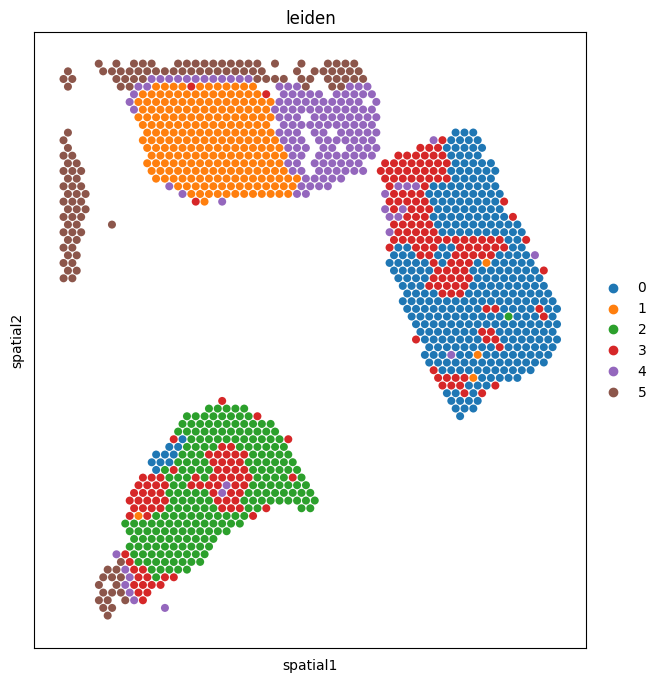

In [13]:
sc.pl.spatial(
    neighbscore_copy,
    img_key="hires",
    color=["leiden"],
    size=1.4,
    alpha_img=0,
)


## 6. Differential expression between domains

Now that every spot carries a domain label, we can ask: **which ligand–target pairs are most characteristic of each domain?** This is a one-vs-rest Wilcoxon test on the score matrix.

### Step 1 — carry the labels back to the original score AnnData

The Leiden labels live on `neighbscore_copy` (the PC-space AnnData). For DE we want the **original score values** in `neighborhood_scores.X`, so copy the labels and clustering metadata across.


In [14]:
neighborhood_scores.obs['leiden'] = neighbscore_copy.obs['leiden']
neighborhood_scores.uns = neighbscore_copy.uns


### Step 2 — rank pairs and plot the heatmap

Reading the heatmap:
- **Rows** = ligand–target pairs (groups of 10 per domain).
- **Columns** = domains.
- Block-diagonal structure (bright on the diagonal, dim off it) tells you each domain has its own signaling signature.

> A `WARNING: No genes found for group ...` just means one cluster didn't have pairs that passed `min_logfoldchange`. It's not a failure — usually a small/noisy domain.


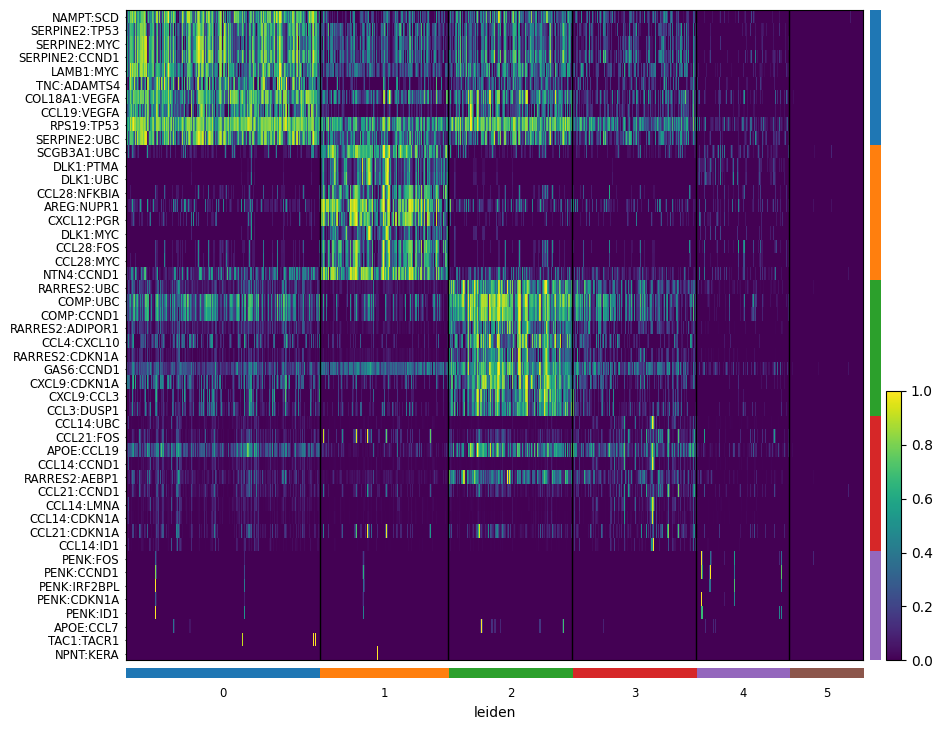

In [15]:
sc.tl.rank_genes_groups(neighborhood_scores, "leiden", method="wilcoxon")

sc.pl.rank_genes_groups_heatmap(
    neighborhood_scores,
    n_genes=10,
    groupby="leiden",
    show_gene_labels=True,
    min_logfoldchange=0.5,
    dendrogram=False,
    swap_axes=True,
    standard_scale='var',
    cmap='viridis',
)


## 7. Pathway activity in space

The `pcs` AnnData from section 4 holds a **per-spot activity score for every pathway cluster**. Painting one of these onto the tissue is often more interpretable than a single L–T pair, because it summarizes a whole biological program.

We'll visualize **`HALLMARK_TNFA_SIGNALING_VIA_NFKB`** and **`De novo cluster 15`**.


/tmp/ipykernel_2546534/2202922046.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


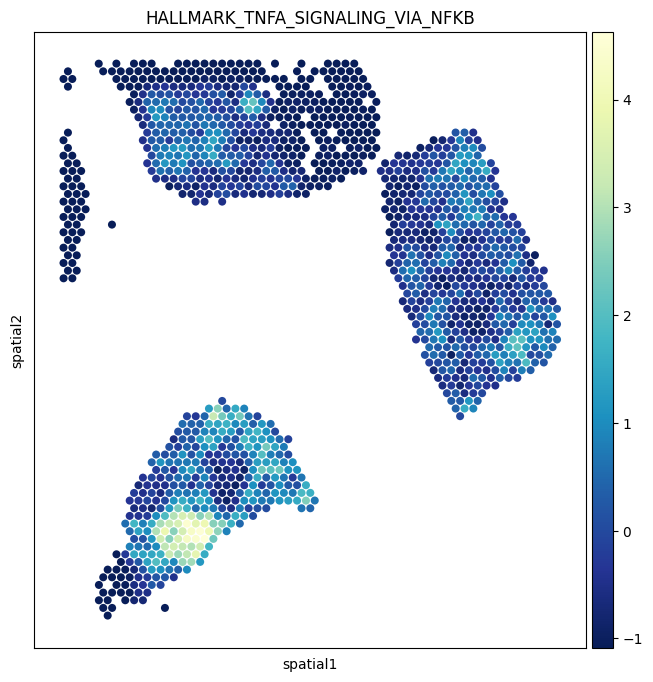

/tmp/ipykernel_2546534/2202922046.py:10: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


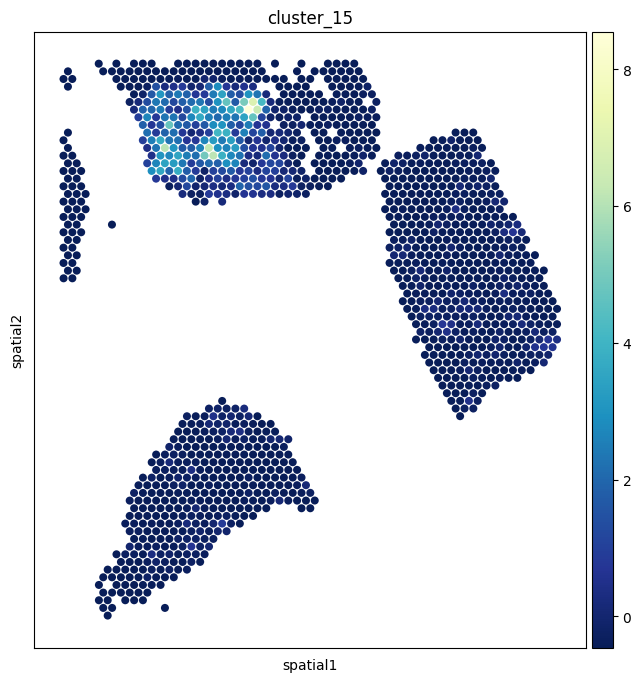

In [20]:
sc.pl.spatial(
    pcs,
    img_key="hires",
    color=['HALLMARK_TNFA_SIGNALING_VIA_NFKB'],
    size=1.4,
    alpha_img=0,
    cmap='YlGnBu_r',
)

sc.pl.spatial(
    pcs,
    img_key="hires",
    color=['cluster_15'],
    size=1.4,
    alpha_img=0,
    cmap='YlGnBu_r',
)

## 8. `Renoir.pcs_v_neighbscore` — Pathway vs. pair contribution

For each pathway cluster, it generates:

1. A **clustermap** showing how individual ligand–target pairs in that pathway contribute to the overall pathway activity across spots — i.e., *which pairs are doing the work*.
2. A **spatial feature plot** of the pathway score for context.

This is invaluable when a pathway looks active in a region: you can immediately see *which specific signaling axes* are responsible, rather than just knowing "IL6/JAK/STAT3 is up here."

### Key arguments

| Argument | Meaning |
|---|---|
| `neighbscore` | The neighborhood-scores AnnData. |
| `ltpair_clusters` | The dict of pathway/de novo clusters from `create_cluster`. |
| `pdf_path=None` | Path to save all plots as a multi-page PDF. **Highly recommended** — there's one figure per pathway, so this dumps a lot of plots. |
| `spatialfeatureplot=True` | Include the spatial map alongside each clustermap. |
| `clustermap=True` | Generate the per-pathway clustermap. |
| `size=1.4` | Spot size for the spatial plots. |
| `colormap` | Colormap for both heatmap and spatial plots (default: Spectral). |


In [28]:
# Save all figures to a PDF — one page per pathway
rd.pcs_v_neighbscore(
    neighborhood_scores,
    ltpair_clusters={k:pathways[k] for k in list(pathways.keys())[0:2]},
    pdf_path='/shared/nr57/Renoir_data/pcs_vs_nbscore_demo.pdf',
    spatialfeatureplot=True,
    clustermap=True,
    size=1.4,
)

HALLMARK_ALLOGRAFT_REJECTION


/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/Renoir/downstream.py:675: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(pc_v_neighb, color = cluster, show = False, size=size, alpha_img=0)


HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION


/home/nr57/.conda/envs/genomics/lib/python3.11/site-packages/Renoir/downstream.py:675: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(pc_v_neighb, color = cluster, show = False, size=size, alpha_img=0)


## 9. `Renoir.ligand_ranking` — Which ligands drive a domain?

The previous tools tell you *what* is happening in each domain. `ligand_ranking` answers **why**: which ligands are most likely driving the signature of a chosen domain?

It works by ranking ligands by how well their predicted target activity explains the marker pairs of the domain, while requiring the receptor is actually expressed in that domain's spots.

### Key arguments

| Argument | Meaning |
|---|---|
| `neighbscore` | The score AnnData with Leiden labels. |
| `celltype` | AnnData of per-spot cell-type proportions. |
| `scrna` | Matched scRNA-seq reference (used for receptor expression). |
| `ligand_receptor_pairs` | NATMI / OmniPath L–R table. |
| `ligand_target_regulatory_potential` | NicheNet-style ligand → target regulatory scores. |
| `domain` | The domain ID to interrogate (string, e.g. `'0'`). |
| `receptor_exp=0.05` | Minimum receptor-expressing spot fraction. Filters out ligands the domain literally can't sense. |
| `markers={'top': 100}` | Use the top-100 marker pairs of the domain as the ranking signal. |
| `domain_celltypes=['top', 5]` | Restrict to the top-5 cell types by abundance in the domain. |
| `celltype_colors` | The palette dict — pass `{'auto': True}` for default colors. |

The output is a multi-panel `matplotlib.Figure`: ligand ranking bars, expressing cell types, and the spatial location of the domain.


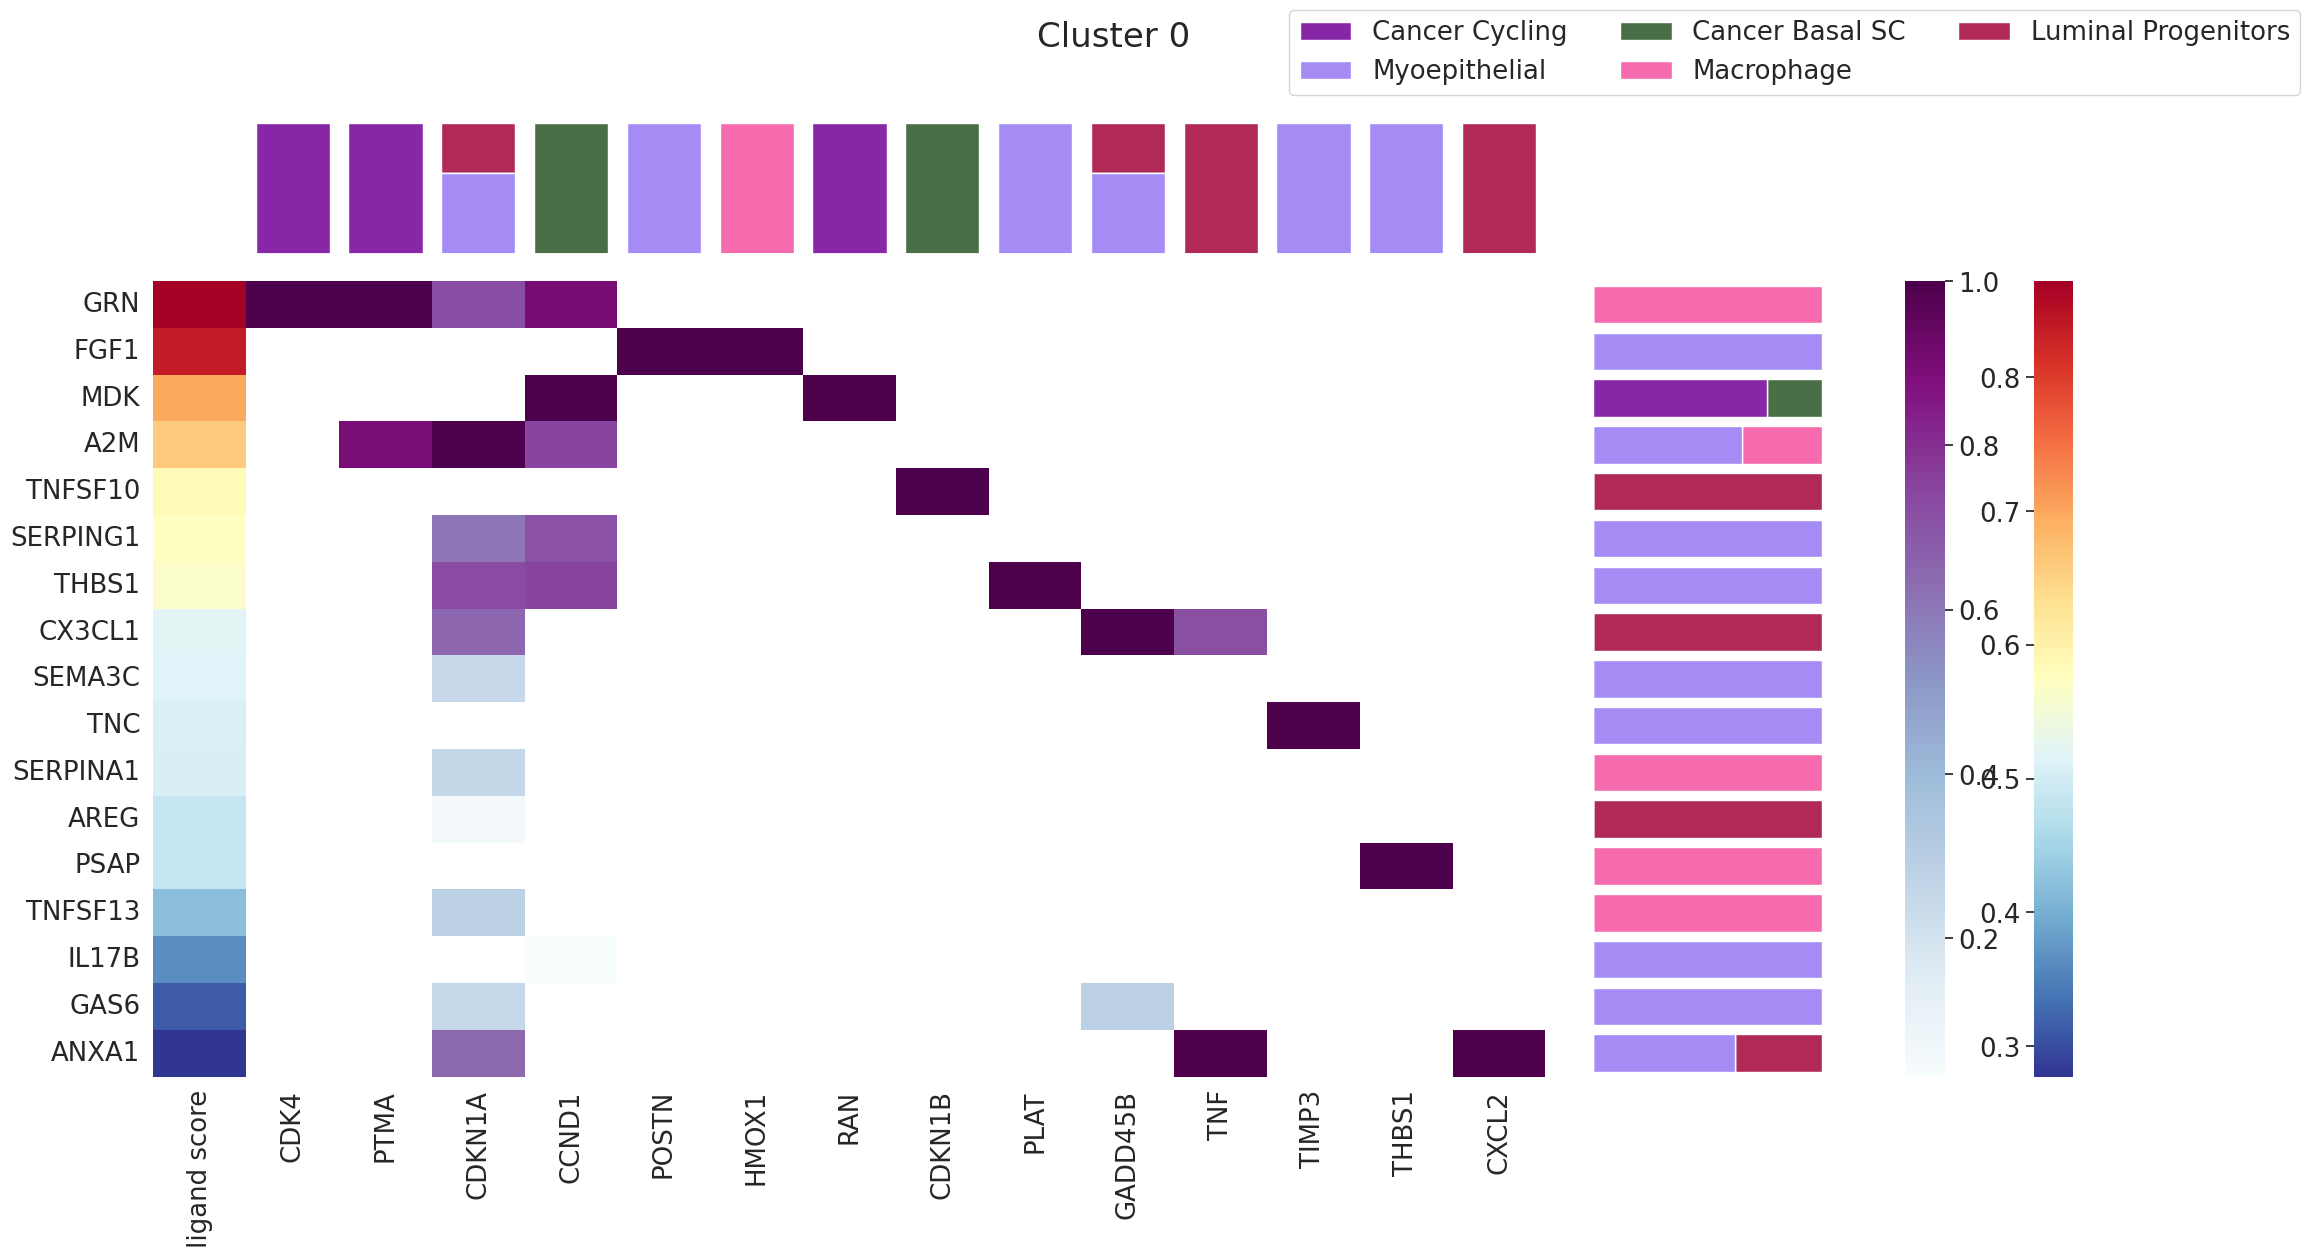

In [29]:
fig = Renoir.ligand_ranking(
    neighborhood_scores,
    celltype,
    SC,
    ligand_receptor_pairs,
    ligand_target_regulatory_potential,
    '0',                          # domain ID — repeat for '1', '2', ... to characterize the whole tissue
    receptor_exp=0.05,
    markers={'top': 100},
    domain_celltypes=['top', 5],
    celltype_colors=celltype_colors,
)
fig.set_size_inches(24, 12)
fig


## 10. `Renoir.downstream.sankeyPlot` — Ligand → target → cell type → domain

The Sankey plot is the **integrative summary view** of Renoir's outputs. It shows the flow:

```
ligand → target → cell type → domain
```

…for a chosen set of L–T pairs, weighted by their activity. Bands' widths are proportional to the activity flowing along each path. This is the figure to put in a paper when you want to convey "here's which ligands act on which targets in which cell types in which niches" all in one image.

### Key arguments

| Argument | Meaning |
|---|---|
| `neighbscore` | Score AnnData with `obs['leiden']` populated. |
| `celltype` | AnnData of per-spot cell-type distributions. |
| `ltpairs` | List of ligand–target pair names to include. **Pick a focused subset** — the plot becomes unreadable with too many pairs. |
| `n_celltype=5` | Top-N cell types to consider per domain. |
| `clusters='All'` | List of domain IDs to include, or `'All'`. |
| `title=None` | Optional plot title. |
| `labelsize=2` | Label size — bump up to 8–12 for legibility. |
| `labelcolor='#000000'` | Text color for labels. |

### Building the L–T pair list

A common pattern: take the top marker pairs from one or two domains of interest and pass those.


In [30]:
# Pull the top 5 marker pairs from each domain to pass into the Sankey
de_results = neighborhood_scores.uns['rank_genes_groups']
top_per_domain = {
    group: list(de_results['names'][group][:5])
    for group in de_results['names'].dtype.names
}

# Flatten and de-duplicate
ltpairs_for_sankey = sorted({pair for pairs in top_per_domain.values() for pair in pairs})
print(f'Sankey will visualize {len(ltpairs_for_sankey)} ligand-target pairs')
ltpairs_for_sankey[:10]


Sankey will visualize 27 ligand-target pairs


['APOE:CCL19',
 'AREG:NUPR1',
 'CCL14:CCND1',
 'CCL14:UBC',
 'CCL21:FOS',
 'CCL28:NFKBIA',
 'CCL4:CXCL10',
 'COMP:CCND1',
 'COMP:UBC',
 'CXCL8:CYP1A1']

In [ ]:
rd.sankeyPlot(
    neighborhood_scores,
    celltype,
    ltpairs_for_sankey,
    n_celltype=5,
    clusters=['0' ,'1', '2'],          # or e.g. ['0', '1', '2'] to focus on specific domains
    title='Top marker ligand-target activity across domains',
    labelsize=10,
    labelcolor='#000000',
)


---

## Wrap-up: the full downstream toolkit at a glance

| Tool | Use it when… |
|---|---|
| `sc.pl.spatial(neighborhood_scores, color=...)` | You want to inspect a **specific** L–T pair in space. |
| `Renoir.create_cluster(... method=None)` | You want to use **curated** pathways from MSigDB. |
| `Renoir.create_cluster(... method='dhc')` | You want **de novo**, data-driven L–T groups. |
| `Renoir.downstream_analysis` | You want **communication domains** (Leiden) + per-pathway scores in one shot. |
| `sc.tl.rank_genes_groups` | You want **DE pairs per domain** with full scanpy flexibility. |
| `Renoir.pcs_v_neighbscore` | You want to know **which pairs drive each pathway** — the pair-level breakdown of pathway activity. |
| `Renoir.ligand_ranking` | You want to know **which ligands drive a specific domain**. |
| `Renoir.downstream.sankeyPlot` | You want a **single integrative figure** of ligand → target → cell type → domain flow. |

### Suggested workflow for a real analysis

1. **Quick look:** `sc.pl.spatial` on a few candidate pairs you already have a hypothesis about.
2. **Group:** `create_cluster` to build pathway and (optionally) de novo clusters.
3. **Cluster spots:** `downstream_analysis` to get domains and per-pathway PCs.
4. **Verify domains:** spatial map of `leiden`; tweak `resolution` until the domains make biological sense.
5. **Characterize each domain:** `rank_genes_groups` heatmap, then `pcs_v_neighbscore` for pathway-level detail.
6. **Find drivers:** `ligand_ranking` for each domain.
7. **Summarize:** one or two `sankeyPlot`s for the paper.

### Where to go from here

- **Compare resolutions:** sweep `resolution` in `downstream_analysis` — coarser/finer domains often surface different biology.
- **Bring in de novo clusters:** rerun the whole pipeline with `all_clusters` (pathway + de novo) to see if data-driven groups expose programs MSigDB misses.
- **Cross-resolution comparison:** if you have a single-cell platform like CosMx for the same tissue, run that tutorial and check which signaling axes survive at higher resolution.
